In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from palettable.wesanderson import Darjeeling2_5
from prettytable import PrettyTable
from scipy.stats import chi2_contingency
from statsmodels.sandbox.regression.predstd import wls_prediction_std
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
import pickle
import joblib
warnings.filterwarnings('ignore')

In [2]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.1)
    Q3 = df[column].quantile(0.9)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

def plot_regression_with_ci(df, group, color, label , model):

    df = df[df['Group'] == group]

    # Get prediction std deviation and intervals
    prstd, iv_l, iv_u = wls_prediction_std(model)
    
    # Plotting
    plt.plot(df['EVENT_ID'].sort_values().values, model.predict(df).loc[df.sort_values('EVENT_ID').index], 'k-', color=color, label=f'{label}')
    #plt.fill_between(df['EVENT_ID'].sort_values().values, iv_l.loc[df.sort_values('EVENT_ID').index], iv_u.loc[df.sort_values('EVENT_ID').index], color=color, alpha=0.05)

def data_availability_plot(data, cutoff, threshold=0.2):
    # Seaborn theme and Wes Anderson palette
    sns.set_theme(style="whitegrid", context="paper")
    sns.set_palette(Darjeeling2_5.mpl_colors)

    fig, (ax1, ax2) = plt.subplots(figsize=(10, 6), ncols=2)

    # Left panel: data availability
    df_plot = pd.DataFrame(
        data.groupby('Group').count().values / data.groupby('Group').size().values.reshape(-1, 1),
        index=[0, 1, 2],
        columns=data.columns[:-1]
    )
    sns.lineplot(data=df_plot.T, ax=ax1)

    ax1.set_xticks(range(len(df_plot.columns)))
    ax1.set_xticklabels(df_plot.columns, rotation=45, ha='right')

    # Ensure tick labels resolved before reading them
    fig.canvas.draw()

    x_ticks = ax1.get_xticks()
    xtick_texts = np.array([t.get_text() for t in ax1.get_xticklabels()])
    ax1.hlines(threshold, x_ticks.min(), x_ticks.max(),
               label='Missingness Cutoff', linestyle='--', color='k')
    ax1.set_title('Data Availability')
    ax1.set_ylabel('Proportion of Samples with Data Available')
    ax1.set_xlabel('Visit Number')

    # Legend: append ' Group' to line labels, keep cutoff label unchanged
    handles, labels = ax1.get_legend_handles_labels()
    labels = [f"Group {int(float(l))}" if l not in ('Missingness Cutoff', '') else l for l in labels]
    ax1.legend(handles, labels)

    # Right panel: subgroup averages
    df_mean = pd.DataFrame(data.groupby('Group').mean()).T
    sns.lineplot(data=df_mean, ax=ax2)

    ax2.set_xticks(range(len(df_plot.columns)))
    ax2.set_xticklabels(df_plot.columns, rotation=45, ha='right')

    y_ticks = ax2.get_yticks()
    ax2.vlines(np.where(xtick_texts == cutoff)[0][0],
               y_ticks.min(), y_ticks.max(),
               label='Timepoint Cutoff', linestyle='--', color='k')
    ax2.set_title('Group Mean Z-Score')
    ax2.set_ylabel('Mean Z-Score')
    ax2.set_xlabel('Visit Number')

    # Legend: append ' Group' to line labels, keep cutoff label unchanged
    handles, labels = ax2.get_legend_handles_labels()
    labels = [f"Group {int(float(l))}" if l not in ('Timepoint Cutoff', '') else l for l in labels]
    ax2.legend(handles, labels)

    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()
    plt.clf

def plot_score_distributions(df_long) : 
    # Seaborn theme and Wes Anderson palette
    sns.set_theme(style="whitegrid", context="paper")
    
    # Prepare data in long form for seaborn
    df_plot = df_long[['Status', 'Status_resid']].rename(
        columns={'Status': 'Raw', 'Status_resid': 'Residual of Sex + Age'}
    )
    df_melt = df_plot.melt(var_name='Measure', value_name='Mean Z-Score').dropna()
    
    # Ensure common bin range across both distributions
    vals = df_melt['Mean Z-Score'].to_numpy()
    vals = vals[np.isfinite(vals)]
    binrange = (np.min(vals), np.max(vals))
    
    # Choose two colors from Darjeeling2_5
    palette = Darjeeling2_5.mpl_colors
    pal_map = {'Raw': palette[0], 'Residual of Sex + Age': palette[3]}
    
    plt.figure(figsize=(9, 5))
    
    # Histograms (matched bins, density-scaled)
    sns.histplot(
        data=df_melt,
        x='Mean Z-Score',
        hue='Measure',
        palette=pal_map,
        bins='fd',
        binrange=binrange,
        stat='density',
        common_norm=False,
        element='poly',
        alpha=0.25,
        edgecolor='white',
        linewidth=0.5
    )
    
    # KDE overlays (no extra legend entries)
    sns.kdeplot(
        data=df_melt,
        x='Mean Z-Score',
        hue='Measure',
        palette=pal_map,
        common_norm=False,
        lw=2,
        legend=True,
        clip=binrange
    )
    
    # Reference line at zero (useful for z-scores)
    plt.axvline(0, color='k', lw=1, ls='--', alpha=0.6)
    
    # Labels and legend
    plt.xlabel('Mean Z-Score')
    plt.ylabel('Density')
    plt.title('Distribution of Status vs Residual (Sex + Age)')
    #handles, labels = plt.gca().get_legend_handles_labels()
    #plt.legend(handles, labels, title='', frameon=False, loc='upper right')
    
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.clf()

def data_process(data, subgroups , events , events_df, print_final_event=True) : 
    events_filt = sorted(list(set(events) & set(data.columns)))
    if print_final_event : 
        print(f'final event : {events_filt[-1]}')
    
    df_long = data.reset_index().melt(id_vars=['Group' ,'PATNO'], var_name='EVENT_ID', value_name='Status')
    
    df_long = pd.merge(df_long , subgroups.reset_index() , left_on = ['PATNO' , 'EVENT_ID' , 'Group'],right_on =['PATNO' , 'EVENT_ID' , 'Group'] , how='outer')
    
    df_long = pd.merge(df_long , events_df , on =['PATNO' , 'EVENT_ID'] , how='outer')
    
    df_long = df_long[df_long['EVENT_ID'].isin(events_filt)]
    
    # Combined linear model, including interaction between predictor and group
    df_long['Group'] = pd.Categorical(df_long['Group'], categories=[0,1,2], ordered=True)

    return df_long

def ols_model_plots(model) : 
    fitted_vals = model.predict()
    residuals = model.resid
    
    fig, (ax1,ax2) = plt.subplots(figsize=(10, 6) , ncols=2)
    ax1.scatter(fitted_vals, residuals, alpha=0.5)
    ax1.hline(0, color='red', linestyle='--')
    ax1.set_xlabel('Fitted Values')
    ax1.set_ylabel('Residuals')
    ax1.set_title('Residuals vs Fitted Values')
    
    sm.qqplot(residuals, line='s', ax=ax2)  # 's' indicates standardized line
    ax2.set_title('Q-Q Plot of Residuals')
    plt.show()

def fa(model, labels , data , part) : 

    keys = [f'Factor_{i}' for i in range(1 , len(labels.keys())+1)]
    columns = [labels[key] for key in keys]

    data_cols = [col for col in data if col not in ['EVENT_ID' , 'PATNO'] and col[-3:] != 'TOT']
    factor_scores = model.transform(data[data_cols].dropna())  # Transform the original data set
    # Create a DataFrame from the scores
    factor_scores_df = pd.DataFrame(factor_scores, columns=columns).add_prefix(f'MDS_UPDRS_P{part}_')
    
    factor_scores_df['PATNO'] = data.dropna(subset=data_cols).reset_index(drop=True)['PATNO']
    factor_scores_df['EVENT_ID'] = data.dropna(subset=data_cols).reset_index(drop=True)['EVENT_ID']
    
    return factor_scores_df

def gen_factors(model = 'PPMI' , data='PPMI' , state='OFF' , model_state_off = False) : 
    with open(f'./../../data/02_processed/{data}/P1_MDSUPDRS.pkl' , 'rb') as file : 
        p1 = pickle.load(file)

    with open(f'./../../data/02_processed/{data}/P2_MDSUPDRS.pkl' , 'rb') as file : 
        p2 = pickle.load(file)
    
    with open(f'./../../data/02_processed/{data}/P3{state}_MDSUPDRS.pkl' , 'rb') as file : 
        p3 = pickle.load(file)

    model_p1 = joblib.load(f"./../../data/03_final/{model}_FA_model_P1.joblib")
    model_p2 = joblib.load(f"./../../data/03_final/{model}_FA_model_P2.joblib")
    if (state == 'ON' or state == 'on') and model_state_off : 
        model_p3 = joblib.load(f"./../../data/03_final/{model}_FA_model_P3OFF.joblib")
    else : 
        model_p3 = joblib.load(f"./../../data/03_final/{model}_FA_model_P3{state}.joblib")

    p1_fa = fa(model_p1['fa'], model_p1['labels'] , p1 , '1')
    p2_fa = fa(model_p2['fa'], model_p2['labels'] , p2 , '2')
    p3_fa = fa(model_p3['fa'], model_p3['labels'] , p3 , '3')

    if data == 'PPMI' : 
        subgroups = pd.read_csv('./../../data/02_processed/PPMI/subgroups.csv', index_col=0)
        events = subgroups['EVENT_ID'].unique()
        x_list = pd.DataFrame(np.arange(0 , 9.5 , 0.5) , index = events , columns=['trajectory'])
        events_df = x_list.reset_index()
        events_df.rename(columns={'index': 'EVENT_ID'}, inplace=True)
        
    elif data == 'OPDC' : 
        subgroups = pd.read_csv('./../../data/02_processed/OPDC/subgroups.csv')
        subgroups['EVENT_ID'] = subgroups['EVENT_ID'].astype(str)
        events = subgroups['EVENT_ID'].unique()
        x_list = pd.DataFrame(np.arange(0 , 9*1.5 , 1.5) , index = events , columns=['trajectory'])
        events_df = x_list.reset_index()
        events_df.rename(columns={'index': 'EVENT_ID'}, inplace=True)

    elif data == 'TRACKING' : 
        subgroups = pd.read_csv('./../../data/02_processed/TRACKING/subgroups.csv' , index_col=0)
        subgroups['EVENT_ID'] = subgroups['EVENT_ID'].astype(str)
        events = ['1','4','7','9','10','11']
        x_list = pd.DataFrame([0,1.5,3,4.5,6,7.5] , index = events , columns=['trajectory'])
        events_df = x_list.reset_index()
        events_df.rename(columns={'index': 'EVENT_ID'}, inplace=True)

    subgroups = subgroups.merge(events_df , on=['EVENT_ID'])
    events_df = subgroups[['PATNO' , 'EVENT_ID', 'trajectory']]
    subgroups.drop(columns='trajectory',inplace=True)

    return pd.merge((pd.merge(p1_fa , p2_fa , on = ['PATNO' , 'EVENT_ID'])), p3_fa , on = ['PATNO' , 'EVENT_ID']) , subgroups, events, events_df

## Train Model

In [5]:
df

,MDS_UPDRS_P1_FATIGUE,MDS_UPDRS_P1_DEPRESSION+ANXIETY,MDS_UPDRS_P1_COGNITION,PATNO,EVENT_ID,MDS_UPDRS_P2_RISE+WALK,MDS_UPDRS_P2_SPEECH,MDS_UPDRS_P2_EAT,MDS_UPDRS_P3_TAPPING_L,MDS_UPDRS_P3_TAPPING_R,MDS_UPDRS_P3_PIG,MDS_UPDRS_P3_RISING,MDS_UPDRS_P3_TREMOR,MDS_UPDRS_P3_NA,combo
0,-1.071660,0.786499,0.234485,3000,BL,-1.166550,-0.508266,-0.532981,-0.406239,-1.090912,-0.921301,-1.373766,-0.781915,-0.038067,-0.686816
1,-0.778408,0.465806,-0.010201,3000,V02,-1.166550,-0.508266,-0.532981,-0.746651,-1.155278,-0.905118,-1.217718,-0.757968,-0.014364,-0.915319
2,-0.485157,0.145113,-0.254887,3000,V04,-1.166550,-0.508266,-0.532981,-1.087063,-1.219643,-0.888935,-1.061670,-0.734021,0.009340,-1.143822
3,-0.784867,0.506675,-0.098574,3000,V05,-1.166550,-0.508266,-0.532981,-0.856133,-1.073023,-0.980411,-1.074235,-0.735726,0.010777,-1.078985
4,-1.084577,0.868238,0.057739,3000,V06,-1.166550,-0.508266,-0.532981,-0.625202,-0.926404,-1.071887,-1.086800,-0.737430,0.012214,-1.014148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9193,0.192943,-0.545212,0.492097,5015,V06,0.629156,1.076925,-0.610468,-0.819114,1.483334,0.025219,0.085731,0.566412,0.086756,0.517316
9194,-1.634457,0.932102,0.809730,5016,BL,2.102846,-0.442550,-0.946182,1.180482,0.690580,0.322677,-0.018611,-0.783125,-0.514869,1.132408
9195,-1.634457,0.932102,0.809730,5016,V02,2.102846,-0.442550,-0.946182,1.180482,0.690580,0.322677,-0.018611,-0.783125,-0.514869,1.132408
9196,-1.188383,-0.278877,-0.435358,5017,BL,-1.196788,-0.547923,-0.388969,-1.664650,-0.844031,-0.080637,-0.093382,-0.050130,-0.214218,-0.515995


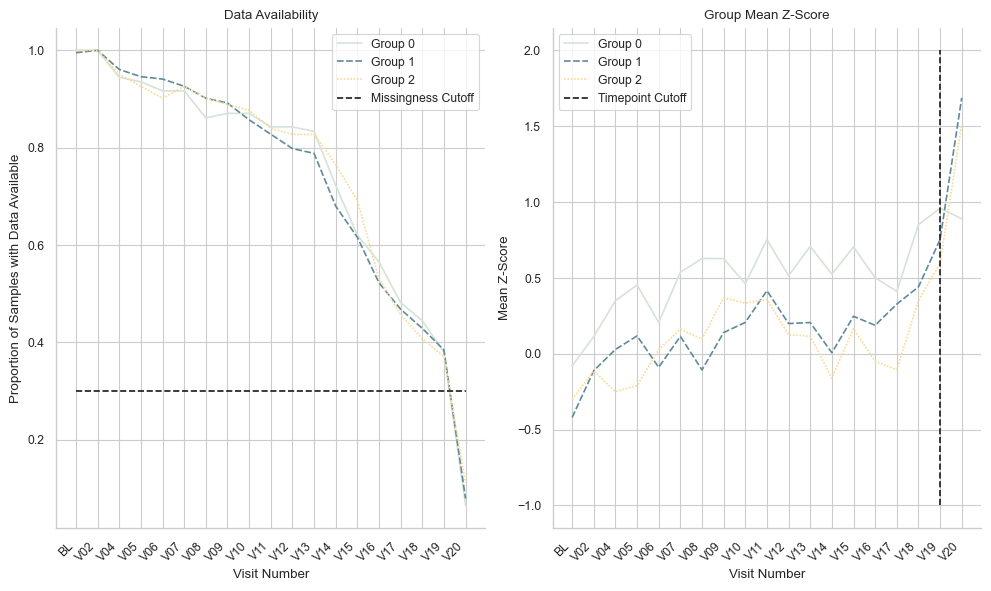

final event : V19


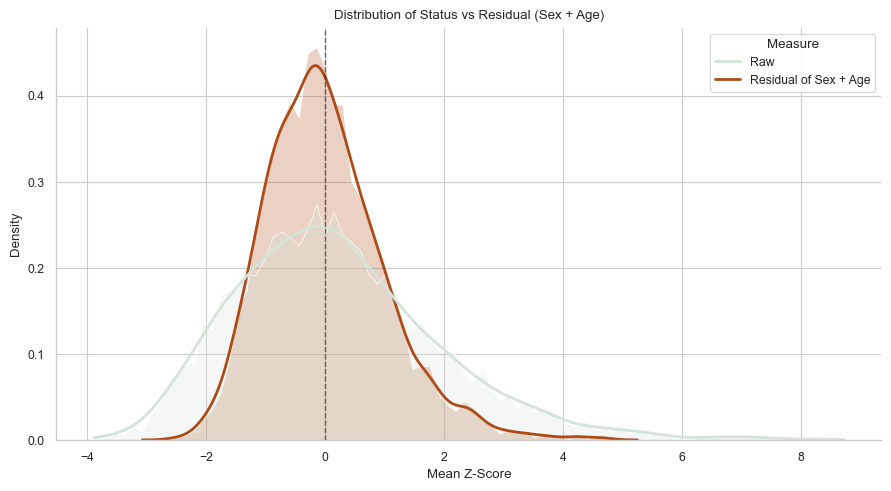

                            OLS Regression Results                            
Dep. Variable:           Status_resid   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     12.68
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           2.86e-12
Time:                        09:05:50   Log-Likelihood:                -7752.3
No. Observations:                5486   AIC:                         1.552e+04
Df Residuals:                    5480   BIC:                         1.556e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

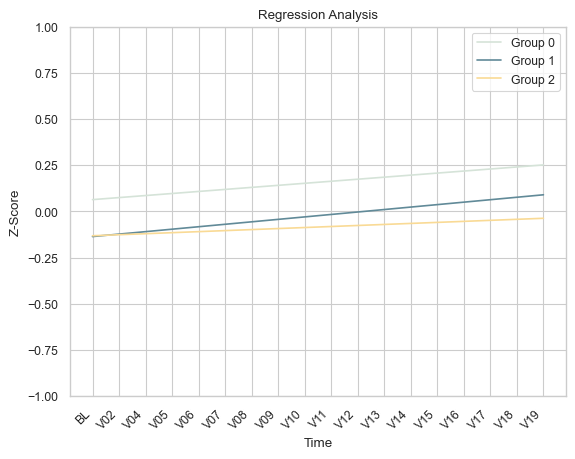

In [7]:
df, subgroups, events, events_df = gen_factors(state='ON' , data='PPMI' , model='PPMI' , model_state_off=False)

factor = 'MDS_UPDRS_P3_TREMOR + MDS_UPDRS_P3_PIG + MDS_UPDRS_P3_RISING'
factor = factor.replace('/','+')

df['combo'] = df.loc[: , factor.split(' + ')].sum(axis=1)
#df['combo'] = df['MDS_UPDRS_P3_PIG']

data = df.pivot_table(values = 'combo', columns = 'EVENT_ID' , index = 'PATNO' , observed=False)
data = pd.merge(data.reset_index() , subgroups.reset_index()[['PATNO' , 'Group']].drop_duplicates() , on='PATNO').set_index('PATNO')

thresh = 0.3
events = list(set(events) & set(data.columns))
events = np.array(events)[data[events].isna().sum() / data.shape[0] <= 1-thresh]
data_availability_plot(data , sorted(list(set(events) & set(data.columns)))[-1] , threshold=thresh)

df_long = data_process(data, subgroups , events , events_df)
df_long.dropna(subset='Status', inplace=True)

df_long['Group'] = pd.Categorical(df_long['Group'], categories=[0,1,2], ordered=True)
model_resid = smf.ols('Status ~  AGE_AT_VISIT + GENDER', data=df_long).fit()
df_long['Status_resid'] = model_resid.resid
df_long['Status_resid'] = (df_long['Status_resid'] - df_long['Status_resid'].mean())/ df_long['Status_resid'].std() 

plot_score_distributions(df_long) 

model_0 = smf.ols('Status_resid ~  trajectory * C(Group)', data=df_long).fit()
print(model_0.summary())

# T1 vs T2: equal slopes?  H0: δ1 = δ2
print('T1 vs T2 (slope equal?)')
print(model_0.t_test('trajectory:C(Group)[T.1] = trajectory:C(Group)[T.2]'))


# Note: To keep color consistency among groups
colors = Darjeeling2_5.mpl_colors

for i , group in enumerate([0,1,2]) : 
    plot_regression_with_ci(df_long, group, color=colors[i], label=f'Group {group}' , model=model_0)

# Additional Plot Settings
plt.xlabel('Time')
plt.ylabel('Z-Score')
plt.ylim(-1,1)
plt.xticks(rotation=45, ha='right')
plt.title('Regression Analysis')
plt.legend()
plt.show()

In [89]:
model_0.t_test('trajectory = trajectory:C(Group)[T.1]').pvalue

array(3.42252714e-07)

In [91]:
print(model_0.t_test('trajectory = trajectory:C(Group)[T.1]').pvalue < 0.05)
print(model_0.t_test('trajectory = trajectory:C(Group)[T.2]').pvalue < 0.05)
print(model_0.t_test('trajectory:C(Group)[T.1] = trajector§y:C(Group)[T.2]').pvalue 0.05)

3.422527135994686e-07
3.5354171454057e-05
0.3518718053456028


## Test Model 

In [101]:
df, subgroups, events, events_df = gen_factors(state='ON' , data='PPMI' , model='PPMI' , model_state_off=False)

df['combo'] = df.loc[: , ('MDS_UPDRS_P3_Factor_4','MDS_UPDRS_P3_Factor_5')].sum(axis=1)
#df['combo'] = df['MDS_UPDRS_P3_Factor_4']

data = df.pivot_table(values = 'combo', columns = 'EVENT_ID' , index = 'PATNO' , observed=False)
data = pd.merge(data.reset_index() , subgroups.reset_index()[['PATNO' , 'Group']].drop_duplicates() , on='PATNO').set_index('PATNO')

thresh = 0.3
events = list(set(events) & set(data.columns))
events = np.array(events)[data[events].isna().sum() / data.shape[0] <= 1-thresh]
data_availability_plot(data , sorted(list(set(events) & set(data.columns)))[-1] , threshold=thresh)

df_long = data_process(data, subgroups , events , events_df)
df_long.dropna(subset='Status', inplace=True)

df_long['Group'] = pd.Categorical(df_long['Group'], categories=[0,1,2], ordered=True)
model_resid = smf.ols('Status ~  AGE_AT_VISIT + GENDER', data=df_long).fit()
df_long['Status_resid'] = model_resid.resid

# Example: compare slopes for B vs C
print(model_0.t_test('trajectory = trajectory:C(Group)[T.1]'))
print(model_0.t_test('trajectory = trajectory:C(Group)[T.2]'))
print(model_2.t_test('trajectory= trajectory:C(Group)[T.1]'))

# Note: To keep color consistency among groups
colors = Darjeeling2_5.mpl_colors

for i , group in enumerate([0,1,2]) : 
    plot_regression_with_ci(df_long, group, color=colors[i], label=f'Group {group}' , model=model)

# Additional Plot Settings
plt.xlabel('Time')
plt.ylabel('Z-Score')
plt.xticks(rotation=45, ha='right')
plt.title('Regression Analysis')
plt.legend()
plt.show()

KeyError: "None of [Index(['MDS_UPDRS_P3_Factor_4', 'MDS_UPDRS_P3_Factor_5'], dtype='object')] are in the [columns]"

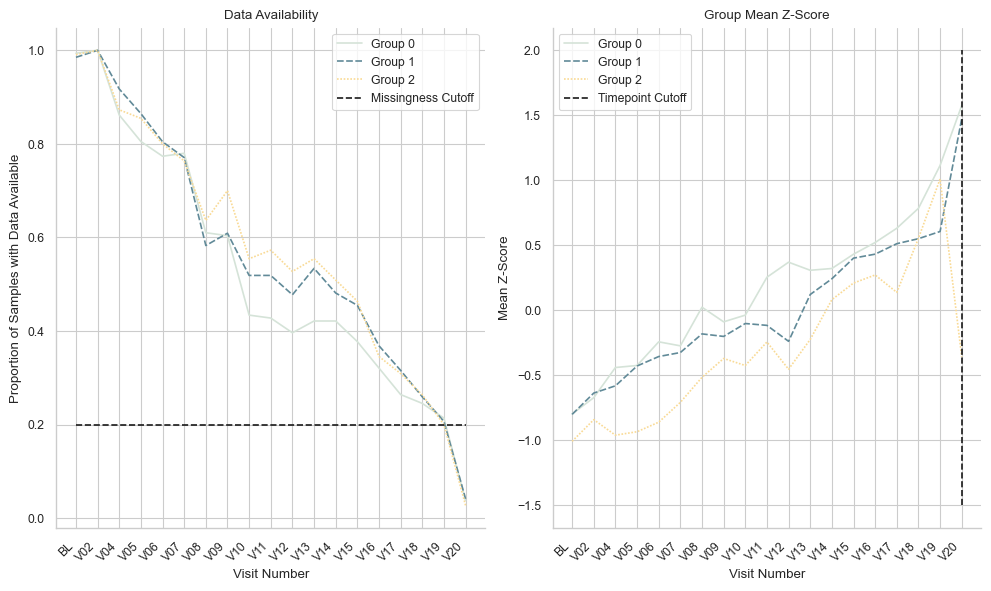

TypeError: data_process() missing 1 required positional argument: 'events_df'

In [499]:
df, subgroups, events, events_df = gen_factors(state='OFF' , data='PPMI' , model='TRACKING')

df['combo'] = df.loc[: , ('MDS_UPDRS_P3_Factor_3' , 'MDS_UPDRS_P1_Factor_1')].sum(axis=1)
data = df.pivot_table(values = 'combo', columns = 'EVENT_ID' , index = 'PATNO' , observed=False)
data = pd.merge(data.reset_index() , subgroups.reset_index()[['PATNO' , 'Group']].drop_duplicates() , on='PATNO').set_index('PATNO')

data_availability_plot(data , sorted(list(set(events) & set(data.columns)))[-1])

df_long = data_process(data , events , events_df)

df_long['Status'].hist()
df_long['Group'] = pd.Categorical(df_long['Group'], categories=[0,1,2], ordered=True)
#model = smf.ols('Status ~  AGE_AT_VISIT + GENDER', data=df_long.dropna()).fit()
#ols_model_plots(model)
#print(model.summary())
#df_long['Status'] = np.sqrt(model.resid + abs(min(model.resid)) + 1)
#df_long['Status'] = model.resid
#df_long['Status'].hist()
model = smf.ols('Status ~  trajectory * C(Group)', data=df_long.dropna(subset='Status')).fit()

print( model.params[3] - model.conf_int().iloc[3])

print(model.params[3] + model.params[4])
print( model.params[4] - model.conf_int().iloc[4])

print(model.params[3] + model.params[5])
print( model.params[5] - model.conf_int().iloc[5])

print(model.summary())
ols_model_plots(model)

df_long['Status'] = df_long['Status'].fillna(model.predict(df_long))
data, data_test = gen_patient_class(df_long , model , data)

data = data[events + list(data.columns[-3:])]
format_as_contingency(data.groupby('Group', observed=False)['Class'].value_counts().reset_index().sort_values(['Group' , 'Class']) , 'Class')
print()

counts = data_test[: , 0]       # Number of vaccinated in each group
nobs = np.sum(data_test , 1)    # Total people in each group

pairwise_proportion_test(counts, nobs)

# Note: To keep color consistency among groups
colors = ['blue', 'green','orange','red','yellow','black']

for i , group in enumerate([0,1,2]) : 
    x = df_long[df_long['Group'] == group][['trajectory']]
    y = df_long[df_long['Group'] == group]['Status']
    plot_regression_with_ci(*(x,y), color=colors[i], label=f'Group {group}')

# Additional Plot Settings
plt.xlabel('Time')
plt.ylabel('Z-Score')
plt.xticks(ticks=np.unique(x['trajectory']), labels=sorted(events), rotation=45, ha='right')
plt.title('Regression Analysis')
plt.legend()
plt.show()